In [1]:
# Base Imports
import os,sys
import numpy as np
import matplotlib.pyplot as plt
import scipy

#Skyllh Imports
from skyllh.core.config import Config
from skyllh.datasets.i3.PublicData_10y_ps import create_dataset_collection
# For power law source model
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis as create_analysis_with_simple_pl
# For custom source model
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps_function_energy_spectrum  import create_analysis as create_analysis_with_custom_mdl

from skyllh.core.source_model import PointLikeSource
from skyllh.core.random import RandomStateService
from skyllh.core.utils.analysis import create_trial_data_file
from skyllh.core.timing import TimeLord
from skyllh.core.utils.analysis import extend_trial_data_file

import matplotlib as mpl
font = {'size'   : 25}
mpl.rc('font', **font) 

In [2]:
import skyllh

In [3]:
os.getcwd()

'/Users/aadesai1/Desktop/In_use/public_IceCube_data/justin_paper_checks'

In [4]:
sources = [["Tycho",6.3208,64.15],       #0, dec +64° 09’
           ["CassA",350.9,58.81],       #1, dec +58° 48’ 41”
           ["IC443",94.3,22.52],       #2, dec +22° 31’ 05”
           ["RX_J1713",17.23,- 39.77],  #3, dec -39° 46’
           ["SN1006",225.7,- 41.95],    #4, dec -41° 57’
           ["Code_test",0.0,0.0]]    #5, dec 0


# Default = Tycho
test_source = 5  #5
source_tested = sources[test_source]

# Optional Parameters for possible tests:
kde_used=False 
#kde_used=True
source_mdl_used = "PL"
#source_mdl_used = "custom" 
#minimizer_used='minuit'
minimizer_used='LBFGS'

In [5]:
# Make possible directories
if os.path.isdir(f'Image_plots')!=True:
    os.mkdir(f'Image_plots')
if os.path.isdir(f'Data_files')!=True:
    os.mkdir(f'Data_files')
if os.path.isdir(f'Cache')!=True:
    os.mkdir(f'Cache')

Create a configuration

In [6]:
help(Config)

Help on class Config in module skyllh.core.config:

class Config(builtins.dict)
 |  Config() -> None
 |  
 |  This class, derived from dict, holds the a local configuration state.
 |  
 |  Method resolution order:
 |      Config
 |      builtins.dict
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self) -> None
 |      Initializes a new Config instance holding the base configuration.
 |  
 |  disable_tracing(self)
 |      Disables the tracing mode of SkyLLH.
 |      
 |      Returns
 |      -------
 |      self : instance of Config
 |          The updated instance of Config.
 |  
 |  enable_tracing(self)
 |      Enables the tracing mode of SkyLLH.
 |      
 |      Returns
 |      -------
 |      self : instance of Config
 |          The updated instance of Config.
 |  
 |  get_wd(self)
 |      Retrieves the absolute path to the working directory as configured in
 |      this configuration.
 |      
 |      Returns
 |      -------
 |      wd : str
 |          Th

In [7]:
cfg = Config()
cfg.set_ncpu(16)
cfg

{'multiproc': {'ncpu': 16},
 'logging': {'log_level': 'INFO',
  'log_format': '%(asctime)s %(processName)s %(name)s %(levelname)s: %(message)s',
  'enable_tracing': False},
 'project': {'working_directory': '.'},
 'repository': {'base_path': None, 'download_from_origin': True},
 'units': {'internal': {'angle': Unit("rad"),
   'energy': Unit("GeV"),
   'length': Unit("cm"),
   'time': Unit("s")},
  'defaults': {'fluxes': {'angle': Unit("rad"),
    'energy': Unit("GeV"),
    'length': Unit("cm"),
    'time': Unit("s")}}},
 'datafields': {'run': 4,
  'ra': 4,
  'dec': 4,
  'ang_err': 4,
  'time': 4,
  'log_energy': 4,
  'true_ra': 8,
  'true_dec': 8,
  'true_energy': 8,
  'mcweight': 8},
 'caching': {'pdf': {'MultiDimGridPDF': False}}}

Load the public Dataset

In [8]:
dsc = create_dataset_collection(
    cfg=cfg,
    base_path='/Users/aadesai1/Desktop/In_use/public_IceCube_data/10yr_public_pstracks')

In [9]:
#Checking data
dsc.dataset_names

['IC40',
 'IC59',
 'IC79',
 'IC86_I',
 'IC86_II',
 'IC86_II-VII',
 'IC86_III',
 'IC86_IV',
 'IC86_V',
 'IC86_VI',
 'IC86_VII']

In [10]:
datasets = dsc['IC40', 'IC59', 'IC79', 'IC86_I', 'IC86_II-VII']
if source_tested[0]=='Code_test':
    datasets = dsc[ 'IC59', 'IC79', 'IC86_I', 'IC86_II', 'IC86_III', 'IC86_IV', 'IC86_V', 'IC86_VI'] 
    # 8 years of data matching https://arxiv.org/pdf/1811.07979

In [11]:
# To check parameters for create_analysis
# help(create_analysis)
name_used= source_tested[0]
ra_used = source_tested[1]
dec_used = source_tested[2]

source = PointLikeSource(name=name_used,ra=np.deg2rad(ra_used), dec=np.deg2rad(dec_used))

In [12]:
source_tested

['Code_test', 0.0, 0.0]

In [13]:
if os.path.isdir(f'Image_plots/{name_used}/')!=True:
    os.mkdir(f'Image_plots/{name_used}/')

In [14]:
print("Energy Model: ",source_mdl_used)
if source_mdl_used=="PL":
    print("Simple Power Law Used")
    E_refrence_val =1000.0
    spectral_index =2.0
    
else:
    print("Custom Model Used")
    print("Setup to be updated in future version")


Energy Model:  PL
Simple Power Law Used


In [15]:
create_analysis = create_analysis_with_simple_pl
#help(create_analysis) # To see details of setup!

In [16]:
if source_mdl_used=="PL":
    ana = create_analysis_with_simple_pl(cfg=cfg, 
                      datasets=datasets, 
                      source=source,
                      refplflux_Phi0=1,             #Flux normalization for model
                      refplflux_E0=E_refrence_val,          # E_0
                      refplflux_gamma=spectral_index,          # spectral index
                      ns_seed=100.0,                # Initial seed
                      ns_min=0.0, 
                      ns_max=1000.0, 
                      gamma_seed=2.0,               # Initial seed
                      gamma_min=2.0,  
                      gamma_max=2.0, 
                      kde_smoothing=kde_used,           # KDE!
                      minimizer_impl=minimizer_used,        # LBFGS or minuit
                      compress_data=True,            
                      keep_data_fields=None,         # additional data field names that should get kept
                      evt_sel_delta_angle_deg=10,    # angle in degrees for the event selection optimization
                      construct_sig_generator=True,
                      tl=None,                       # TimeLord instance to use to time
                      ppbar=None,                    # ProgressBar 
                      logger_name=None)
else:
    print("Custom Model Used")
    print("Setup to be updated in future version")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 92.82it/s]


In [17]:
# Just to check for custom model:
#ana.shg_mgr.get_fluxmodel_by_src_idx(0).energy_profile(E=10**6).squeeze()*10**6*10**6


In [18]:
#np.log10(eng_interst[np.argmax(nu_flux_val)])

# Calculating the sensitivity/Differential Sensitivity


### First Generate Background Trials

In [19]:
trials_directory = f'Cache/{name_used}_trials/'
data_directory = f'Data_files/{name_used}/'
if os.path.isdir(trials_directory)!= True:
    os.mkdir(trials_directory)
if os.path.isdir(f'Data_files/{name_used}/')!=True:
    os.mkdir(f'Data_files/{name_used}/')
    
bkg_pathfilename = f'{trials_directory}/bkg_trials.npy'
tl = TimeLord()
rss = RandomStateService(seed=1)


if os.path.isfile(bkg_pathfilename)!=True and os.path.isfile(f'{data_directory}/bkg_trials.npy')!=True:
    trials = create_trial_data_file(ana=ana,
                                     rss=rss,
                                     n_trials=1e4,
                                     mean_n_sig=0,
                                     pathfilename=bkg_pathfilename,
                                     ncpu=8,
                                     tl=tl)
if os.path.isfile(f'{data_directory}/bkg_trials.npy')!=True:
    trials = np.load(bkg_pathfilename)
else:
    trials = np.load(f'{data_directory}/bkg_trials.npy')


while len(trials['ns'])<1e5:
    print(len(trials['ns']))
    trials = extend_trial_data_file(ana=ana,
                                rss=rss,
                                n_trials=1e4,
                                trial_data=trials,
                                pathfilename=bkg_pathfilename,
                                ncpu=8,
                                tl=tl)
    if os.path.isfile(f'{data_directory}/bkg_trials.npy')!=True:
        trials = np.load(bkg_pathfilename)
    else:
        trials = np.load(f'{data_directory}/bkg_trials.npy')
    print("Final:",len(trials['ns']),"\n\n")

if os.path.isfile(f'{data_directory}/bkg_trials.npy')!=True:
    os.rename(bkg_pathfilename, f'{data_directory}/bkg_trials.npy')



In [20]:
num_trials = len(trials['ns'])

In [21]:
bkg_ts=trials['ts']
bkg_ns=trials['ns']
bkg_mean_n_sig=trials['mean_n_sig']
bkg_gamma=trials['gamma']


In [22]:
import histlite as hl

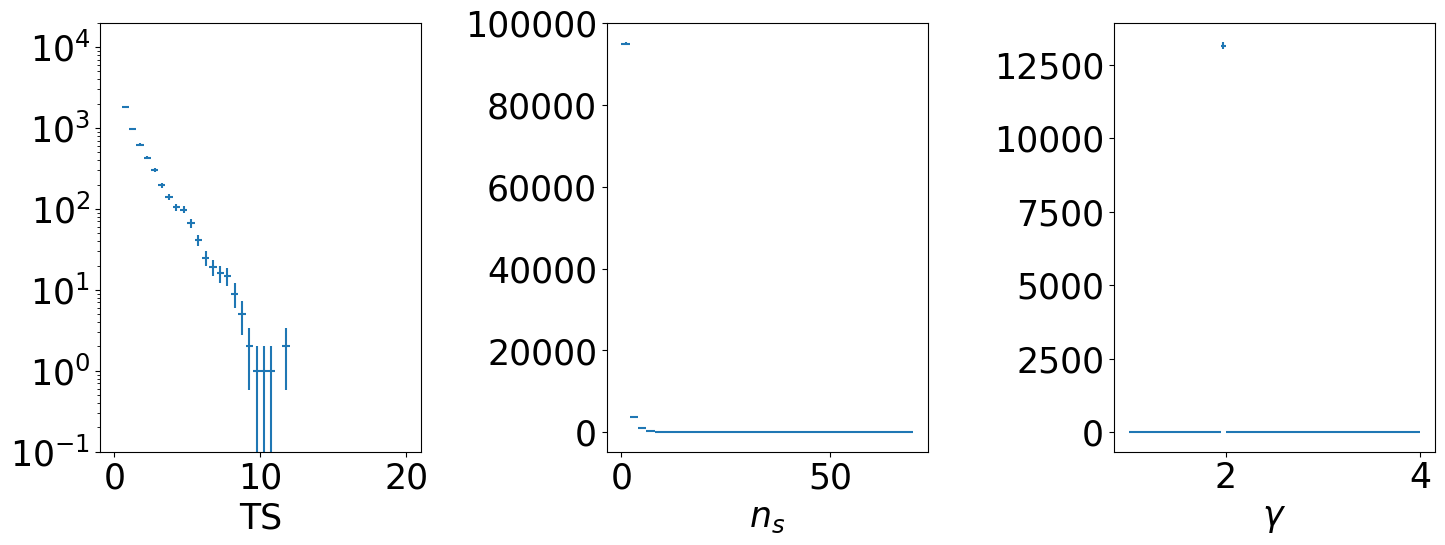

In [23]:

fig, axs = plt.subplots(1, 3, figsize=(15,6))

if source_mdl_used=="PL":
    h_gamma = hl.hist(bkg_gamma[bkg_ns > 0], bins=np.r_[1:4.01:.05])
else:
    h_epeak = hl.hist(bkg_epeak[bkg_ns > 0], bins=np.r_[3:10.01:.1])

h_ts = hl.hist(bkg_ts, bins=np.r_[:20.1:.5])
h_ns = hl.hist(bkg_ns, bins=np.r_[:70.1:2])

hl.plot1d(axs[0], h_ts, crosses=True)
hl.plot1d(axs[1], h_ns, crosses=True)
if source_mdl_used=="PL":
    hl.plot1d(axs[2], h_gamma, crosses=True)
    axs[2].set_xlabel(r'$\gamma$')
else:
    hl.plot1d(axs[2], h_epeak, crosses=True)
    axs[2].set_xlabel(r'E$_{peak}$')

axs[0].set_xlabel("TS")
axs[1].set_xlabel(r'$n_s$')



axs[0].set_ylim(1e-1, 2e4)
axs[0].semilogy()
#axs[1].semilogy()
plt.tight_layout()
if kde_used==True:
    plt.savefig(f'Image_plots/{name_used}/bkg_TS_ns_g_dist_{num_trials}_trials_sig_with_kde.png')
else:
    plt.savefig(f'Image_plots/{name_used}/bkg_TS_ns_g_dist_{num_trials}_trials_sig_no_kde.png')


### Next calculate sensitivity

In [24]:
from skyllh.core.utils.analysis import estimate_sensitivity,estimate_discovery_potential 

rss = RandomStateService(seed=2)

In [25]:
energy_bins = np.logspace(3,9,13)
energy_bins

array([1.00000000e+03, 3.16227766e+03, 1.00000000e+04, 3.16227766e+04,
       1.00000000e+05, 3.16227766e+05, 1.00000000e+06, 3.16227766e+06,
       1.00000000e+07, 3.16227766e+07, 1.00000000e+08, 3.16227766e+08,
       1.00000000e+09])

## Running Signal Trials!

In [26]:
# energy_bins = np.logspace(3,9,13) #Energy bins in GeV

sig_trials_directory = f'Cache/{name_used}_trials/'
sig_data_directory = f'Data_files/{name_used}/sig_trials/'
if os.path.isdir(sig_trials_directory)!= True:
    os.mkdir(sig_trials_directory)
if os.path.isdir(sig_data_directory)!=True:
    os.mkdir(sig_data_directory)
        
sig_trails = []

for i in range(len(energy_bins)):
    if i==0:
        continue
    emin_used = energy_bins[i-1]
    emax_used = energy_bins[i]

    
    
    try:
        del ana
    except:
        print("old ana deleted")

    ana = create_analysis_with_simple_pl(cfg=cfg, 
                      datasets=datasets, 
                      source=source,
                      refplflux_Phi0=1,             #Flux normalization for model
                      refplflux_E0=E_refrence_val,          # E_0
                      refplflux_gamma=spectral_index,          # spectral index
                      ns_seed=100.0,                # Initial seed
                      ns_min=0.0, 
                      ns_max=1000.0, 
                      gamma_seed=2.0,               # Initial seed
                      gamma_min=2.0,  
                      gamma_max=2.0, 
                      energy_range=(emin_used,emax_used),
                      kde_smoothing=kde_used,           # KDE!
                      minimizer_impl=minimizer_used,        # LBFGS or minuit
                      compress_data=True,            
                      keep_data_fields=None,         # additional data field names that should get kept
                      evt_sel_delta_angle_deg=10,    # angle in degrees for the event selection optimization
                      construct_sig_generator=True,
                      tl=None,                       # TimeLord instance to use to time
                      ppbar=None,                    # ProgressBar 
                      logger_name=None)

    
    sig_kwargs = {'energy_range': (emin_used,emax_used)}
    print(f'Running bin {emin_used} - {emax_used}')
    combined=[]
    for indi_signal_value in [1,2,3,4,5,6,7,8,9,10,12,15,20,25,30,60]:
        if os.path.isfile(f'{sig_trials_directory}/sens_sig_trials_{emin_used}_{emax_used}_n_sig_{indi_signal_value}.npy')!=True and os.path.isfile(f'{sig_data_directory}/sens_sig_trials_{emin_used}_{emax_used}_n_sig_{indi_signal_value}.npy')!=True:
            trials = create_trial_data_file(ana=ana,
                                     rss=rss,
                                     n_trials=1e3,
                                     mean_n_sig=float(indi_signal_value),
                                     sig_kwargs=sig_kwargs,
                                     pathfilename=f'{trials_directory}/sens_sig_trials_{emin_used}_{emax_used}_n_sig_{indi_signal_value}.npy',
                                     ncpu=16,
                                     tl=tl)
            
        elif os.path.isfile(f'{sig_trials_directory}/sens_sig_trials_{emin_used}_{emax_used}_n_sig_{indi_signal_value}.npy')!=True:
            trials = np.load(f'{sig_data_directory}/sens_sig_trials_{emin_used}_{emax_used}_n_sig_{indi_signal_value}.npy')
        else:
            trials = np.load(f'{sig_trials_directory}/sens_sig_trials_{emin_used}_{emax_used}_n_sig_{indi_signal_value}.npy')
        

        
        
        combined.append(trials)
    os.system(f'mv {sig_trials_directory}/sens_sig_trials_* {sig_data_directory}/')
    sig_trails.append(combined)
    
    
    

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 85.94it/s]
mv: rename Cache/Code_test_trials//sens_sig_trials_* to Data_files/Code_test/sig_trials//sens_sig_trials_*: No such file or directory


Running bin 1000.0 - 3162.2776601683795


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 84.14it/s]
mv: rename Cache/Code_test_trials//sens_sig_trials_* to Data_files/Code_test/sig_trials//sens_sig_trials_*: No such file or directory


Running bin 3162.2776601683795 - 10000.0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 74.93it/s]
mv: rename Cache/Code_test_trials//sens_sig_trials_* to Data_files/Code_test/sig_trials//sens_sig_trials_*: No such file or directory


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 72.85it/s]
mv: rename Cache/Code_test_trials//sens_sig_trials_* to Data_files/Code_test/sig_trials//sens_sig_trials_*: No such file or directory


Running bin 100000000.0 - 316227766.01683795


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 67.18it/s]

Running bin 316227766.01683795 - 1000000000.0



mv: rename Cache/Code_test_trials//sens_sig_trials_* to Data_files/Code_test/sig_trials//sens_sig_trials_*: No such file or directory


## Calculating Sensitivity

In [27]:
from scipy.interpolate import interp1d

In [28]:
# Load Bkg trials
bkg_trials = np.load(f'{data_directory}/bkg_trials.npy')
ts_bkg = bkg_trials['ts']
ts_threshold = np.median(ts_bkg)


print("Median background TS =", ts_threshold)

#Load Sensitivity
sensitivity = []
gamma_vals =[]
for i in range(len(energy_bins)):
    if i==0:
        continue
    emin_used = energy_bins[i-1]
    emax_used = energy_bins[i]
    
    ns_vals=[]
    probs=[]
    for indi_signal_value in [1,2,3,4,5,6,7,8,9,10,12,15,20,25,30,60]:
        trials = np.load(f'{sig_data_directory}/sens_sig_trials_{emin_used}_{emax_used}_n_sig_{indi_signal_value}.npy')
        injected_ns = trials['mean_n_sig'][0]
        ts = trials['ts']

        prob = np.mean(ts > ts_threshold)

        ns_vals.append(injected_ns)
        probs.append(prob)

        print(injected_ns, prob)
    

    ns_vals = np.array(ns_vals)
    probs = np.array(probs)

    interp = interp1d(probs, ns_vals)

    try: 
        ns_sensitivity = interp(0.9)
    except:
        print(f'bin {emin_used} - {emax_used}',"Sens not found")
        sensitivity.append(0.0)
    else:
        print(f'Running bin {emin_used} - {emax_used}')
        print("Sensitivity =", ns_sensitivity)
        sensitivity.append(ns_sensitivity)
    

    #print(ns_vals,probs)

Median background TS = 0.0
1.0 0.341
2.0 0.547
3.0 0.69
4.0 0.744
5.0 0.808
6.0 0.864
7.0 0.912
8.0 0.93
9.0 0.954
10.0 0.959
12.0 0.978
15.0 0.993
20.0 1.0
25.0 1.0
30.0 1.0
60.0 1.0
Running bin 1000.0 - 3162.2776601683795
Sensitivity = 6.75
1.0 0.354
2.0 0.526
3.0 0.642
4.0 0.758
5.0 0.818
6.0 0.885
7.0 0.898
8.0 0.932
9.0 0.939
10.0 0.966
12.0 0.98
15.0 0.997
20.0 0.999
25.0 1.0
30.0 1.0
60.0 1.0
Running bin 3162.2776601683795 - 10000.0
Sensitivity = 7.0588235294117645
1.0 0.389
2.0 0.532
3.0 0.655
4.0 0.725
5.0 0.824
6.0 0.86
7.0 0.918
8.0 0.934
9.0 0.951
10.0 0.964
12.0 0.98
15.0 0.997
20.0 0.999
25.0 1.0
30.0 1.0
60.0 1.0
Running bin 10000.0 - 31622.776601683792
Sensitivity = 6.689655172413793
1.0 0.368
2.0 0.535
3.0 0.665
4.0 0.76
5.0 0.835
6.0 0.857
7.0 0.915
8.0 0.918
9.0 0.953
10.0 0.965
12.0 0.981
15.0 0.995
20.0 1.0
25.0 1.0
30.0 1.0
60.0 1.0
Running bin 31622.776601683792 - 100000.0
Sensitivity = 6.741379310344827
1.0 0.343
2.0 0.543
3.0 0.647
4.0 0.76
5.0 0.833
6.0 0.88
7

In [29]:
# To see how flux normalization works
#help(ana.calculate_fluxmodel_scaling_factor)

In [30]:
# Sensitivity Fluxes:
(ts, x, status) = ana.unblind(minimizer_rss=rss)
scaling_factor = ana.calculate_fluxmodel_scaling_factor()*sensitivity[0]

#flux_sensitivity = np.array(sensitivity) / sensitivity[0] * scaling_factor

# Flux Sensitivity \n $(E/1000 GeV)^{-2.0}$ 1/(GeV s cm^2 sr)
# So multiplying by 1e6 will give TeV/cm2/s

In [35]:
flux_sensitivity = np.asarray(sensitivity)
for i in range(len(energy_bins)):
    if i==0:
        continue
    emin_used = energy_bins[i-1]
    emax_used = energy_bins[i]

    
    #"""
    try:
        del ana
    except:
        print("old ana deleted")

    ana = create_analysis_with_simple_pl(cfg=cfg, 
                      datasets=datasets, 
                      source=source,
                      refplflux_Phi0=1,             #Flux normalization for model
                      refplflux_E0=0.5 * (emin_used + emax_used),          # E_0
                      refplflux_gamma=spectral_index,          # spectral index
                      ns_seed=100.0,                # Initial seed
                      ns_min=0.0, 
                      ns_max=1000.0, 
                      gamma_seed=2.0,               # Initial seed
                      gamma_min=2.0,  
                      gamma_max=2.0, 
                      energy_range=(emin_used,emax_used),
                      kde_smoothing=kde_used,           # KDE!
                      minimizer_impl=minimizer_used,        # LBFGS or minuit
                      compress_data=True,            
                      keep_data_fields=None,         # additional data field names that should get kept
                      evt_sel_delta_angle_deg=10,    # angle in degrees for the event selection optimization
                      construct_sig_generator=True,
                      tl=None,                       # TimeLord instance to use to time
                      ppbar=None,                    # ProgressBar 
                      logger_name=None)

    #"""
    print(ana.calculate_fluxmodel_scaling_factor(),sensitivity[i-1])
    flux_sensitivity[i-1] = ana.calculate_fluxmodel_scaling_factor()*sensitivity[i-1]
    flux_sensitivity[i-1] = ana.mu2flux(sensitivity[i-1])

    # FLux is ins GeV-1 cm-2 s-1 sr-1
    # But str deltafunction normalizes to 1 so that can be removed by multiplying 1
    # If the reference energy used is 1 TeV, then multiplying by 1e3 changes the units to TeV and then multiplying by E^2 where E is 1 TeV should give E2dn/de

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 88.33it/s]


4.246600801219234e-21 6.75


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 86.98it/s]


1.4524798297515497e-21 7.0588235294117645


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 87.33it/s]


...

1.2648482957588845e-25 6.964285714285714


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 70.08it/s]


4.0047214370207235e-26 6.583333333333333


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 72.09it/s]

1.2416232447070933e-26 6.823529411764706


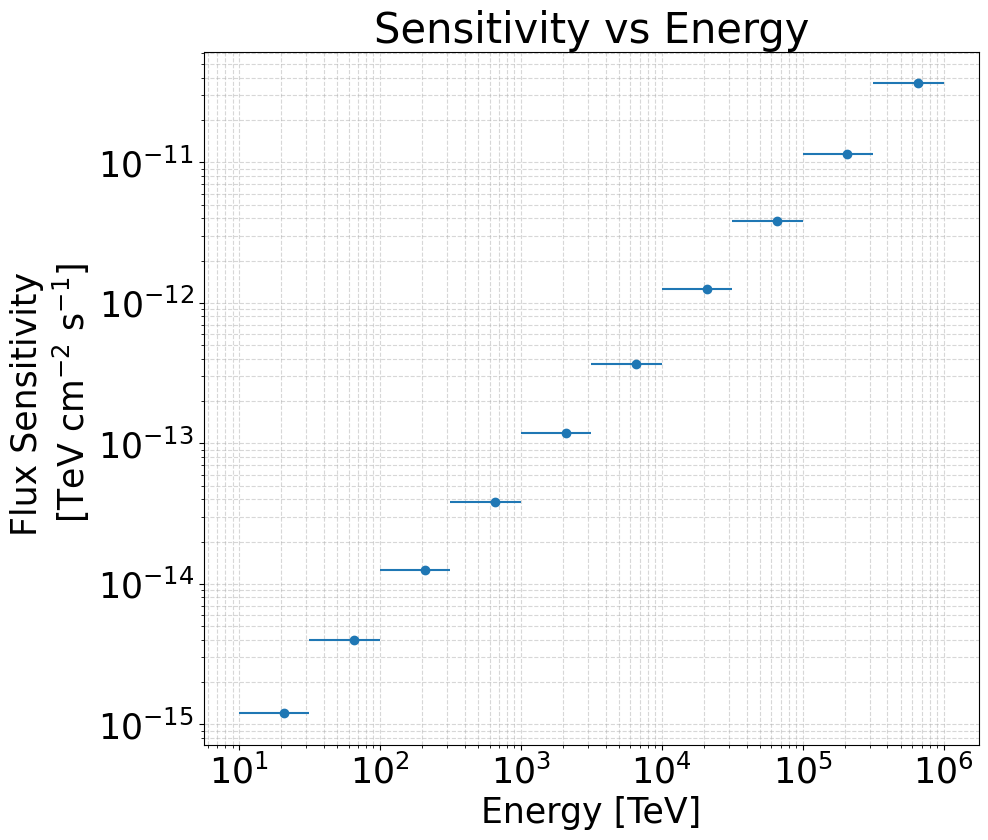

In [74]:
energy_centers = 0.5 * (energy_bins[1:] + energy_bins[:-1])
emin = (energy_centers-energy_bins[:-1])/1e3
emax = (energy_bins[1:]-energy_centers)/1e3

plt.figure(figsize=(10,9))
plt.errorbar(energy_centers[2:]/1e3, (energy_centers[2:]/1e3)**2*flux_sensitivity[2:]*1e3, xerr=np.asarray([emin[2:],emax[2:]]), marker='o', linestyle='')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [TeV]')
plt.ylabel('Flux Sensitivity \n [TeV cm$^{-2}$ s$^{-1}$]')
plt.title('Sensitivity vs Energy')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig(f'Image_plots/{name_used}/sensitivity_flux_vs_e.png')
plt.show()

In [72]:
energy_centers-emin

array([1.00000000e+03, 3.16227766e+03, 1.00000000e+04, 3.16227766e+04,
       1.00000000e+05, 3.16227766e+05, 1.00000000e+06, 3.16227766e+06,
       1.00000000e+07, 3.16227766e+07, 1.00000000e+08, 3.16227766e+08])

In [33]:
os.getcwd()

'/Users/aadesai1/Desktop/In_use/public_IceCube_data/justin_paper_checks'

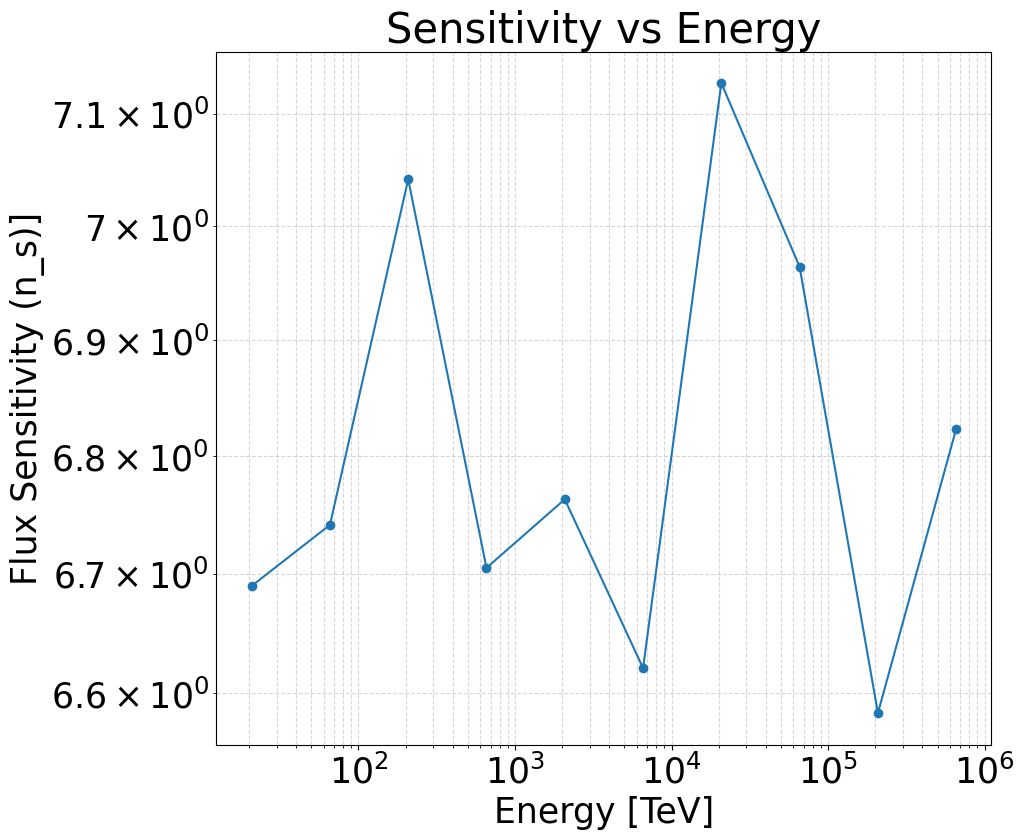

In [34]:
plt.figure(figsize=(10,9))
plt.plot(energy_centers[2:]/1e3, sensitivity[2:], marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [TeV]')
plt.ylabel('Flux Sensitivity (n_s)]')
plt.title('Sensitivity vs Energy')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig(f'Image_plots/{name_used}/sensitivity_ns_vs_e.png')
plt.show()

# If using Test Code, Stop analysis here

In [ ]:
ana = create_analysis_with_simple_pl(cfg=cfg, 
                      datasets=datasets, 
                      source=source,
                      refplflux_Phi0=1,             #Flux normalization for model
                      refplflux_E0=E_refrence_val,          # E_0
                      refplflux_gamma=spectral_index,          # spectral index
                      ns_seed=100.0,                # Initial seed
                      ns_min=0.0, 
                      ns_max=1000.0, 
                      gamma_seed=2.0,               # Initial seed
                      gamma_min=2.0,  
                      gamma_max=2.0, 
                      kde_smoothing=kde_used,           # KDE!
                      minimizer_impl=minimizer_used,        # LBFGS or minuit
                      compress_data=True,            
                      keep_data_fields=None,         # additional data field names that should get kept
                      evt_sel_delta_angle_deg=10,    # angle in degrees for the event selection optimization
                      construct_sig_generator=True,
                      tl=None,                       # TimeLord instance to use to time
                      ppbar=None,                    # ProgressBar 
                      logger_name=None)

### Initializing a trial

After the Analysis instance was created trials can be run. To do so the analysis needs to be initialized with some trial data. For instance we could initialize the analysis with the experimental data to “unblind” the analysis afterwards. Technically the TrialDataManager of each log-likelihood ratio function, i.e. dataset, is initialized with data.

The Analysis class provides the method initialize_trial to initialize a trial with data. It takes a list of DataFieldRecordArray instances holding the events. If we want to initialize a trial with the experimental data, we can get that list from the Analysis instance itself:

In [ ]:
events_list = [ data.exp for data in ana.data_list ]
ana.initialize_trial(events_list)

### Maximizing the log-likelihood ratio function

After initializing a trial, we can maximize the LLH ratio function using the maximize_llhratio method of the Analysis class. This method requires a RandomStateService instance in case the minimizer does not succeed and a new set of initial values for the fit parameters need to get generated. The method returns a 4-element tuple. The first element is the set of fit parameters used in the maximization. The second element is the value of the LLH ration function at its maximum. The third element is the array of the fit parameter values at the maximum, and the forth element is the status dictionary of the minimizer.

In [ ]:
from skyllh.core.random import RandomStateService
rss = RandomStateService(seed=10)

In [ ]:
(log_lambda_max, fitparam_values, status) = ana.llhratio.maximize(rss)

In [ ]:
print(f'log_lambda_max = {log_lambda_max}')
print(f'fitparam_values = {fitparam_values}')
print(f'status = {status}')

In [ ]:
TS = ana.calculate_test_statistic(log_lambda_max, fitparam_values)
print(f'TS = {TS:.3f}')

### Unblinding the data and Getting Best Fit Values! 

After creating the analysis instance we can unblind the data for the choosen source. Hence, we initialize the analysis with a trial of the experimental data, maximize the log-likelihood ratio function for all given experimental data events, and calculate the test-statistic value. The analysis instance has the method unblind that can be used for that. 

In [ ]:
rss = RandomStateService(seed=1)

In [ ]:
#help(ana.unblind)

In [ ]:
(ts, x, status) = ana.unblind(minimizer_rss=rss)
print(ts, x, status)

In [ ]:
print(f'TS = {ts:.3f}')
print(f'ns = {x["ns"]:.2f}')
if source_mdl_used=="PL":
    print(f'gamma = {x["gamma"]:.2f}')
else:
    print(f'e_peak = {x["e_peak"]:.2f}')
    

In [ ]:
x

In [ ]:
scipy.stats.chi2.ppf(0.68, df=2)

In [ ]:
minus_log10_pval = -np.log10(len(trials[trials['ts'] > ts]) / len(trials))
print(f'-log10(p_local) = {minus_log10_pval:.2f}')



In [ ]:
plt.figure(figsize=(10,7))
(h, be) = np.histogram(trials['ts'], bins=np.arange(0, np.max(trials['ts'])+0.1, 0.1))
plt.plot(0.5*(be[:-1]+be[1:]), h, drawstyle='steps-mid', label='background')
plt.vlines(ts, 1, np.max(h), label=f'TS({source_tested})={ts:.3f}')
plt.yscale('log')
plt.xlabel('TS')
plt.ylabel('#trials per bin')
plt.legend()
if kde_used==True:
    plt.savefig(f'Image_plots/{name_used}/bkg_TS_dist_{num_trials}_trials__with_kde.png')
else:
    plt.savefig(f'Image_plots/{name_used}/bkg_TS_dist_{num_trials}_trials_sig_no_kde.png')

# Calculating the corresponding flux normalization

By default the analysis is created with a flux normalization of 1 GeV-1s-1cm-2sr-1 
(see refplflux_Phi0 argument of the create_analysis method). 
The analysis instance has the method calculate_fluxmodel_scaling_factor that 
calculates the scaling factor the reference flux normalization has to be 
multiplied with to represent a given analysis result, i.e. and  value. 
This function takes the detected mean  value as first argument and the list of source parameter values as second argument:

In [ ]:
if source_mdl_used=="PL":
    scaling_factor = ana.calculate_fluxmodel_scaling_factor(x['ns'], [x['ns'], x['gamma']])
else:
    print("To be updated")
print(f'Flux scaling factor = {scaling_factor:.3e}')

In [ ]:
if source_mdl_used!="PL":
    ana.calculate_fluxmodel_scaling_factor(2, [2000, x['e_peak']])

In [ ]:
if source_mdl_used!="PL":
    ana.shg_mgr.get_fluxmodel_by_src_idx(0).energy_profile(E=10**x['e_peak']).squeeze()

In [ ]:
if source_mdl_used=="PL":
    print(f'{scaling_factor:.3e}'' (E/1000 GeV)^{-'f'{x["gamma"]:.2f}'+'} 1/(GeV s cm^2 sr)')
    err_lo = ana.calculate_fluxmodel_scaling_factor(x['ns']-15, [x['ns'], x['gamma']])
    err_hi = ana.calculate_fluxmodel_scaling_factor(x['ns']+15, [x['ns'], x['gamma']])
    print(f'{scaling_factor:.3e}+{err_lo:.3e}-{err_hi:.3e} ''(E/1000 GeV)^{-'f'{x["gamma"]:.2f}'+'} 1/(GeV s cm^2 sr)')

else:
    print("To be updated")
    



### Evaluating the log-likelihood ratio function
Sometimes it is useful to be able to evaluate the log-likelihood ratio function, e.g. for creating a likelihood contour plot. Because SkyLLH’s structure is based on the mathematical structure of the likelihood function, the Analysis instance has the property llhratio which is the class instance of the used log-likelihood ratio function. This instance has the method evaluate. The method takes an array of the fit parameter values as argument at which the LLH ratio function will be evaluated. It returns the value of the LLH ratio function at the given point and its gradients w.r.t. the fit parameters.

In our case this is the number of signal events, 
 and the spectral index 
. If we evaluate the LLH ratio function at the maximum, the gradients should be close to zero.



In [ ]:
help(ana.llhratio.evaluate)

In [ ]:

if source_mdl_used=="PL":
    (llhratio_value, (grad_ns, grad_gamma)) = ana.llhratio.evaluate([14.58, 2.17])
    print(f'llhratio_value = {llhratio_value:.3f}')
    print(f'grad_ns = {grad_ns:.3f}')
    print(f'grad_gamma = {grad_gamma:.3f}')
else:
    print("To be updated")

In [ ]:
fitparam_values

Using the evaluate method of the LLHRatio class we can scan the log-likelihood ratio space and create a contour plot showing the best fit and the 68%, 90%, and 95% quantile assuming Wilks-theorem.



In [ ]:
source_mdl_used

In [ ]:

(ns_min, ns_max, ns_step) = (1, 80, 0.5)
#(ns_min, ns_max, ns_step) = (1, 180, 1.0)
if source_mdl_used=="PL":
    (gamma_min, gamma_max, gamma_step) = (1.5, 4.0, 0.1)
else: 
    print("To be updated")    

ns_edges = np.linspace(ns_min, ns_max, int((ns_max-ns_min)/ns_step)+1)
ns_vals = 0.5*(ns_edges[1:] + ns_edges[:-1])

if source_mdl_used=="PL":
    gamma_edges = np.linspace(gamma_min, gamma_max, int((gamma_max-gamma_min)/gamma_step+1))
    gamma_vals = 0.5*(gamma_edges[1:] + gamma_edges[:-1])
    delta_ts = np.empty((len(ns_vals), len(gamma_vals)), dtype=np.double)
    for (ns_i, ns) in enumerate(ns_vals):
        for (gamma_i, gamma) in enumerate(gamma_vals):
            delta_ts[ns_i, gamma_i] = (
                ana.calculate_test_statistic(llhratio_value, fitparam_values) -
                ana.calculate_test_statistic(ana.llhratio.evaluate([ns, gamma])[0], [ns, gamma])
                )
    # Determine the best fit ns and gamma values from the scan.
    index_max = np.argmin(delta_ts)
    ns_i_max = int(index_max / len(gamma_vals))
    gamma_i_max = index_max % len(gamma_vals)
    ns_best = ns_vals[ns_i_max]
    gamma_best = gamma_vals[gamma_i_max]
else:
    print("To be updated")



In [ ]:
# Determine the delta lambda value for the 95% quantile assuming a chi-sqaure
# distribution with 2 degrees of freedom (i.e. assuming Wilks theorem).
if source_mdl_used=="PL":
    df_used = 2
else:
    df_used = 1
chi2_68_quantile = scipy.stats.chi2.ppf(0.68, df=df_used)
chi2_90_quantile = scipy.stats.chi2.ppf(0.90, df=df_used)
chi2_95_quantile = scipy.stats.chi2.ppf(0.95, df=df_used)

In [ ]:

from matplotlib.colors import LogNorm
if source_mdl_used=="PL":
    plt.figure(figsize=(8,6))
    plt.pcolormesh(gamma_edges, ns_edges, delta_ts, cmap='plasma')
    cbar = plt.colorbar()
    cbar.set_label(r'$\Delta$TS')
    plt.contour(gamma_vals, ns_vals, delta_ts, [chi2_68_quantile], colors='#FFFFFF')
    plt.contour(gamma_vals, ns_vals, delta_ts, [chi2_90_quantile], colors='#AAAAAA')
    plt.contour(gamma_vals, ns_vals, delta_ts, [chi2_95_quantile], colors='#444444')
    plt.plot(gamma_best, ns_best, marker='x', color='white', ms=10)
    plt.xlabel(r'$\gamma$')
    plt.ylabel(r'$n_{\mathrm{s}}$')
    plt.ylim(ns_min, ns_max)
    plt.xlim(gamma_min, gamma_max)

    if kde_used==True:
        plt.savefig(f'Image_plots/{name_used}/ns_gamma_likelihood_with_kde.png')
    else:
        plt.savefig(f'Image_plots/{name_used}/ns_gamma_likelihood_no_kde.png')
else:
    print("To be updated")